## Signals, Filtering, and the Fourier Duality

A signal $x[n]$ and its DFT $X[k]$ carry identical information in two complementary forms:

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j2\pi kn/N} \qquad\quad
  x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X[k]\, e^{j2\pi kn/N}$$

**Convolution theorem** — the central identity of all filtering:

$$y[n] = (h \ast x)[n] \;\longleftrightarrow\; Y[k] = H[k] \cdot X[k]$$

Every filter is *convolution in one domain* and *pointwise multiplication in the other*.
Where you choose to operate determines the trade-offs: frequency selectivity, time localisation, and artefact type.

**Parseval's theorem** — energy is preserved across the transform:

$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N}\sum_{k=0}^{N-1} |X[k]|^2$$

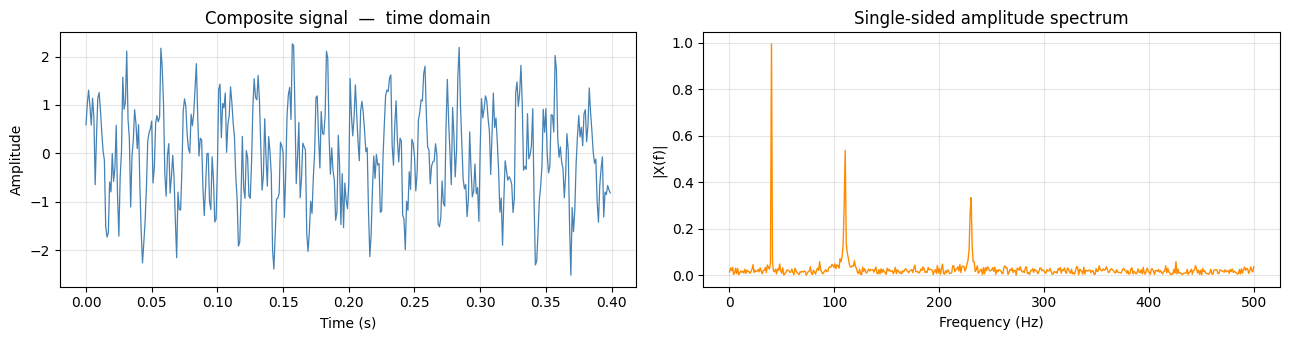

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
import ipywidgets as widgets

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True,
                     'grid.alpha': 0.3, 'figure.max_open_warning': 0})

fs, N = 1000, 1024
t     = np.arange(N) / fs
freqs = np.fft.rfftfreq(N, 1 / fs)

np.random.seed(7)
signal = (  np.sin(2 * np.pi *  40 * t)
          + 0.7 * np.sin(2 * np.pi * 110 * t)
          + 0.5 * np.sin(2 * np.pi * 230 * t)
          + 0.35 * np.random.randn(N))

def amp_spectrum(x):
    return np.abs(np.fft.rfft(x)) * 2 / N

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
ax1.plot(t[:400], signal[:400], lw=0.9, color='steelblue')
ax1.set(xlabel='Time (s)', ylabel='Amplitude',
        title='Composite signal  —  time domain')
ax2.plot(freqs, amp_spectrum(signal), lw=1, color='darkorange')
ax2.set(xlabel='Frequency (Hz)', ylabel='|X(f)|',
        title='Single-sided amplitude spectrum')
plt.tight_layout()
plt.show()

## Time-Domain Filtering — Sculpting the Spectrum via Convolution

Convolving with a kernel $h[n]$ of length $M$ multiplies the spectrum by $H(f) = \mathcal{F}\{h\}$:

$$y[n] = \sum_{m=0}^{M-1} h[m]\, x[n-m] \quad\longleftrightarrow\quad Y(f) = H(f) \cdot X(f)$$

| Kernel | $h[n]$ | $|H(f)|$ | Trade-off | <br>
| Rectangular | $\frac{1}{M}$ for $0 \le n < M$ | $|\mathrm{sinc}(fM/f_s)|$ — sidelobes | Sharp time boundary; spectral leakage | <br>
| Gaussian | $e^{-n^2/2\sigma^2}$ (normalised) | Gaussian — no sidelobes | Smooth roll-off; no ringing | <br>

Larger $M$ or $\sigma$ → narrower passband → stronger temporal blurring.
This trade-off is the **time–frequency uncertainty principle**:

$$\Delta t \cdot \Delta f \;\geq\; \frac{1}{4\pi}$$

In [2]:
@widgets.interact(
    kernel=widgets.RadioButtons(
        options=['gaussian', 'rectangular'], value='gaussian',
        description='Kernel:', style={'description_width': 'initial'}),
    width=widgets.IntSlider(
        min=3, max=151, step=2, value=21, description='Kernel width M',
        style={'description_width': 'initial'}, layout=widgets.Layout(width='60%')),
)
def time_domain_filter(kernel='gaussian', width=21):
    plt.close('all')
    if kernel == 'rectangular':
        h = np.ones(width) / width
    else:
        sigma = width / 6.0
        idx   = np.arange(width) - width // 2
        h     = np.exp(-idx**2 / (2 * sigma**2))
        h    /= h.sum()

    filtered = fftconvolve(signal, h, mode='same')

    H_mag  = np.abs(np.fft.rfft(h, n=N))
    H_mag /= H_mag.max()

    fig, axes = plt.subplots(2, 2, figsize=(13, 7))

    axes[0, 0].plot(t[:400], signal[:400],   alpha=0.5, lw=0.9, label='Original', color='steelblue')
    axes[0, 0].plot(t[:400], filtered[:400], lw=1.8,    label='Filtered',  color='tomato')
    axes[0, 0].set(xlabel='Time (s)', ylabel='Amplitude', title='Time Domain')
    axes[0, 0].legend()

    k_idx = np.arange(width) - width // 2
    axes[0, 1].stem(k_idx, h, linefmt='C1-', markerfmt='C1o', basefmt='k-')
    axes[0, 1].set(xlabel='Sample  n', ylabel='h[n]',
                   title=f'Kernel  ({kernel},  M = {width})')

    axes[1, 0].plot(freqs, amp_spectrum(signal),   alpha=0.5, lw=0.9, label='Original', color='steelblue')
    axes[1, 0].plot(freqs, amp_spectrum(filtered), lw=1.8,    label='Filtered',  color='tomato')
    axes[1, 0].set(xlabel='Frequency (Hz)', ylabel='|X(f)|', title='Frequency Domain')
    axes[1, 0].legend()

    axes[1, 1].plot(freqs, H_mag, lw=1.8, color='seagreen')
    axes[1, 1].fill_between(freqs, H_mag, alpha=0.15, color='seagreen')
    axes[1, 1].set(xlabel='Frequency (Hz)', ylabel='|H(f)| (norm.)',
                   title='Frequency Response of Kernel')

    plt.tight_layout()
    plt.show()

interactive(children=(RadioButtons(description='Kernel:', options=('gaussian', 'rectangular'), style=Descripti…

## Frequency-Domain Filtering — Masking and Its Time-Domain Cost

Multiplying the spectrum by a mask $M[k]$ is equivalent to time-domain convolution with $m[n] = \mathcal{F}^{-1}\{M\}$:

$$Y[k] = M[k] \cdot X[k] \;\xrightarrow{\;\mathcal{F}^{-1}\;}\; y[n] = m[n] \ast x[n]$$

The mask shape determines the **equivalent impulse response** $m[n]$ — the filter viewed from the time side.

An **ideal brick-wall** ($M[k] = \mathbf{1}_{|k| \le k_c}$) achieves perfect frequency selectivity, but its time-domain equivalent is a sinc with *infinite support* — truncation produces **Gibbs oscillations** (ringing).

A **Butterworth mask** of order $n$ gives a tunable roll-off:

$$M(f) = \frac{1}{1 + \bigl(f / f_c\bigr)^{2n}}$$

Higher $n$ → steeper spectral roll-off → longer, more oscillatory impulse response in time.
This is the same uncertainty principle seen from the dual perspective.

In [3]:
@widgets.interact(
    cutoff=widgets.IntSlider(
        min=10, max=450, step=5, value=80, description='Cutoff fc (Hz)',
        style={'description_width': 'initial'}, layout=widgets.Layout(width='60%')),
    order=widgets.IntSlider(
        min=1, max=20, step=1, value=2, description='Roll-off order n',
        style={'description_width': 'initial'}, layout=widgets.Layout(width='60%')),
)
def freq_domain_filter(cutoff=80, order=2):
    plt.close('all')
    mask     = 1.0 / (1.0 + (freqs / cutoff) ** (2 * order))
    X        = np.fft.rfft(signal)
    Y        = X * mask
    filtered = np.fft.irfft(Y, n=N)

    mask_sym     = np.concatenate([mask, mask[-2:0:-1]])
    impulse_resp = np.fft.fftshift(np.fft.ifft(mask_sym).real)
    c            = len(impulse_resp) // 2
    ir_win       = impulse_resp[c - 80: c + 81]
    ir_ms        = np.arange(-80, 81) / fs * 1000

    energy_ratio = (np.trapezoid(amp_spectrum(filtered) ** 2, freqs) /
                    np.trapezoid(amp_spectrum(signal)   ** 2, freqs))

    fig, axes = plt.subplots(2, 2, figsize=(13, 7))

    axes[0, 0].plot(t[:400], signal[:400],   alpha=0.5, lw=0.9, label='Original', color='steelblue')
    axes[0, 0].plot(t[:400], filtered[:400], lw=1.8,
                    label=f'Filtered  (energy: {energy_ratio:.1%})', color='tomato')
    axes[0, 0].set(xlabel='Time (s)', ylabel='Amplitude', title='Time Domain')
    axes[0, 0].legend()

    axes[0, 1].plot(ir_ms, ir_win, lw=1.5, color='mediumpurple')
    axes[0, 1].axhline(0, color='k', lw=0.5)
    axes[0, 1].set(xlabel='Time (ms)', ylabel='m[n]',
                   title='Equivalent Impulse Response  m[n]')

    axes[1, 0].plot(freqs, amp_spectrum(signal),   alpha=0.5, lw=0.9, label='Original', color='steelblue')
    axes[1, 0].plot(freqs, amp_spectrum(filtered), lw=1.8,    label='Filtered',  color='tomato')
    axes[1, 0].set(xlabel='Frequency (Hz)', ylabel='|X(f)|', title='Frequency Domain')
    axes[1, 0].legend()

    axes[1, 1].plot(freqs, mask, lw=2, color='seagreen')
    axes[1, 1].fill_between(freqs, mask, alpha=0.15, color='seagreen')
    axes[1, 1].axvline(cutoff, color='tomato', lw=1.2, ls='--', label=f'fc = {cutoff} Hz')
    axes[1, 1].set(xlabel='Frequency (Hz)', ylabel='M(f)',
                   title=f'Butterworth Mask  (order {order})')
    axes[1, 1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=80, description='Cutoff fc (Hz)', layout=Layout(width='60%'), max=450, m…

## Gaussian Self-Duality and the Uncertainty Bound

The Gaussian is the **only function that saturates** $\Delta t \cdot \Delta f = 1/(4\pi)$. Its Fourier transform is again a Gaussian — making the duality perfectly concrete:

$$h[n] = e^{-n^2/2\sigma_t^2} \;\longleftrightarrow\; H(f) \propto e^{-2\pi^2 \sigma_t^2 f^2 / f_s^2}$$

The frequency-domain width is reciprocally linked to the time-domain width:

$$\boxed{\;\sigma_f = \frac{f_s}{2\pi\,\sigma_t} \qquad\Rightarrow\qquad \sigma_t \cdot \sigma_f = \frac{f_s}{2\pi} = \mathrm{const.}\;}$$

Dragging the slider changes $\sigma_t$ and simultaneously — unavoidably — changes $\sigma_f$ in the opposite direction. Both domains are shown at once.

In [ ]:
@widgets.interact(
    sigma_t=widgets.FloatSlider(
        min=1.0, max=60.0, step=0.5, value=10.0,
        description='sigma_t (samples)',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='65%')),
)
def gaussian_duality(sigma_t=10.0):
    plt.close('all')
    half  = min(int(4 * sigma_t) + 5, N // 2 - 1)
    k_idx = np.arange(-half, half + 1)
    h     = np.exp(-k_idx**2 / (2 * sigma_t**2))
    h    /= h.sum()

    filtered = fftconvolve(signal, h, mode='same')

    H_mag  = np.abs(np.fft.rfft(h, n=N))
    H_mag /= H_mag.max()

    sigma_f      = fs / (2 * np.pi * sigma_t)
    product      = sigma_t * sigma_f
    energy_ratio = (np.trapezoid(amp_spectrum(filtered) ** 2, freqs) /
                    np.trapezoid(amp_spectrum(signal)   ** 2, freqs))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(k_idx, h / h.max(), lw=2, color='mediumpurple')
    axes[0].fill_between(k_idx, h / h.max(), alpha=0.2, color='mediumpurple')
    axes[0].axvline(-sigma_t, color='k', lw=0.9, ls='--', alpha=0.5, label=f'±σ_t = ±{sigma_t:.0f}')
    axes[0].axvline( sigma_t, color='k', lw=0.9, ls='--', alpha=0.5)
    axes[0].set(xlabel='Sample offset', ylabel='h[n] (norm.)',
                title=f'Gaussian kernel   σ_t = {sigma_t:.1f} samples')
    axes[0].legend(fontsize=9)

    axes[1].plot(t[:500], signal[:500],   alpha=0.4, lw=0.8, label='Original', color='steelblue')
    axes[1].plot(t[:500], filtered[:500], lw=1.8,    label='Filtered',  color='tomato')
    axes[1].set(xlabel='Time (s)', ylabel='Amplitude',
                title=f'Time domain   (energy retained: {energy_ratio:.1%})')
    axes[1].legend(fontsize=9)

    axes[2].plot(freqs, amp_spectrum(signal),   alpha=0.4, lw=0.8, label='Original', color='steelblue')
    axes[2].plot(freqs, amp_spectrum(filtered), lw=1.8,    label='Filtered',  color='tomato')
    ax2r = axes[2].twinx()
    ax2r.plot(freqs, H_mag, lw=1.5, color='seagreen', ls='--', label='|H(f)|')
    ax2r.axvline(sigma_f, color='seagreen', lw=1.0, ls=':', alpha=0.85)
    ax2r.annotate(
        f'σ_f ≈ {sigma_f:.1f} Hz',
        xy=(sigma_f, 0.58), xytext=(min(sigma_f + 15, 440), 0.75),
        fontsize=8, color='seagreen',
        arrowprops=dict(arrowstyle='->', color='seagreen', lw=0.8),
    )
    ax2r.set(ylabel='|H(f)| (norm.)', ylim=(0, 1.35))
    lines1, lbl1 = axes[2].get_legend_handles_labels()
    lines2, lbl2 = ax2r.get_legend_handles_labels()
    axes[2].legend(lines1 + lines2, lbl1 + lbl2, fontsize=8)
    axes[2].set(xlabel='Frequency (Hz)', ylabel='|X(f)|',
                title=f'Frequency domain   σ_f ≈ {sigma_f:.1f} Hz')

    plt.suptitle(
        f'σ_t = {sigma_t:.1f} samples  ×  σ_f ≈ {sigma_f:.1f} Hz'
        f'   ⟹   σ_t · σ_f ≈ {product:.1f}   (const. = fs / 2π ≈ {fs / (2 * np.pi):.1f})',
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=10.0, description='sigma_t (samples)', layout=Layout(width='65%'), max…